## Data import

In [49]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /Users/janzawadzki/.cache/kagglehub/datasets/meharshanali/student-dropout-prediction-dataset/versions/1
['student_dropout_dataset_v3.csv']


In [4]:
file_path = os.path.join(path, 'student_dropout_dataset_v3.csv')
df = pd.read_csv(file_path)

## EDA

In [5]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [6]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [8]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [9]:
df["Family_Income"] = df["Family_Income"].fillna(df["Family_Income"].median())
df["Study_Hours_per_Day"] = df["Study_Hours_per_Day"].fillna(df["Study_Hours_per_Day"].median())
df["Stress_Index"] = df["Stress_Index"].fillna(df["Stress_Index"].median())

In [10]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income              0
Internet_Access            0
Study_Hours_per_Day        0
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index               0
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [11]:
df["Parental_Education"] = df["Parental_Education"].fillna("Unknown")

In [12]:
df.Parental_Education.value_counts()

Parental_Education
Bachelor       3949
High School    3072
Master         2003
Unknown         511
PhD             465
Name: count, dtype: int64

In [13]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [14]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [15]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [16]:
df["Internet_Access"] = df["Internet_Access"].map({"Yes": 1, "No": 0})
df["Part_Time_Job"] = df["Part_Time_Job"].map({"Yes": 1, "No": 0})
df["Scholarship"] = df["Scholarship"].map({"Yes": 1, "No": 0})

In [17]:
df["Semester"] = df["Semester"].map({"Year 1": 1, "Year 2": 2, "Year 3": 3, "Year 4": 4,})

In [18]:
df = pd.get_dummies(df, columns=["Department"], dtype=int)

In [19]:
df["Parental_Education"] = df["Parental_Education"].map({
    "Unknown": 0,
    "High School": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4
})

In [20]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,Semester_GPA,CGPA,Semester,Parental_Education,Dropout,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science
0,1,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,...,0.90,0.90,1,1,0,1,0,0,0,0
1,2,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,...,1.20,1.19,3,2,1,0,0,0,1,0
2,3,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,...,1.32,1.32,1,3,0,1,0,0,0,0
3,4,24.4,1,29740.5,1,4.00,82.2,2,38.6,0,...,1.77,1.77,1,1,1,0,0,1,0,0
4,5,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,...,0.91,0.87,4,2,0,0,1,0,0,0


In [21]:
df.drop(columns='Student_ID', inplace=True)

## Model selection


In [22]:
df.Dropout.value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

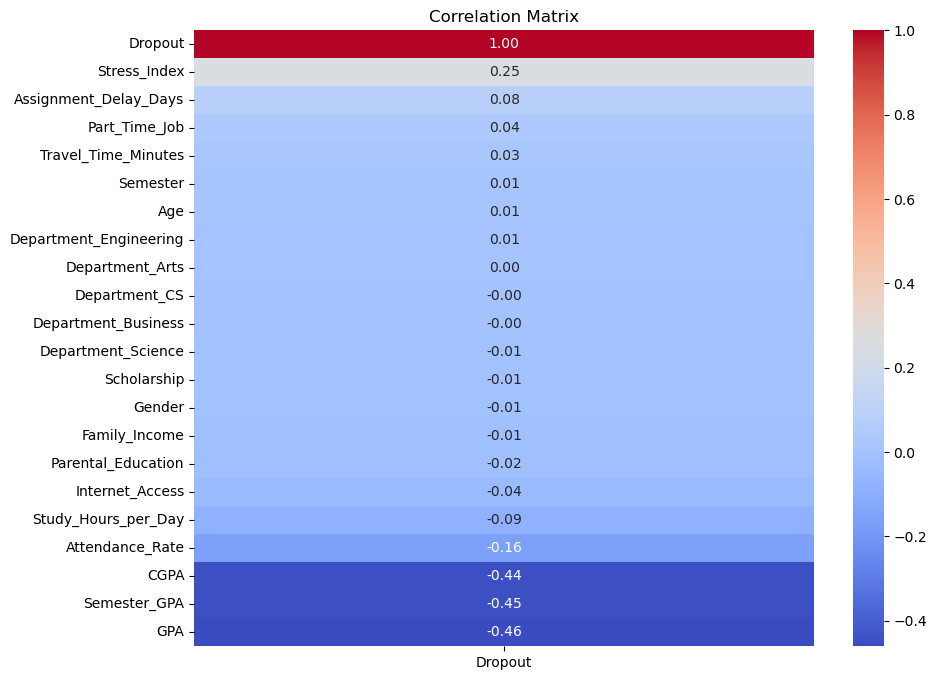

In [ ]:
corr = df.corr(numeric_only=True)[["Dropout"]].sort_values(by="Dropout",ascending=False)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Dropout")
plt.show()

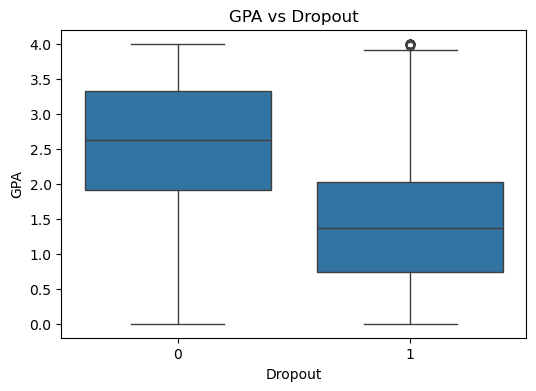

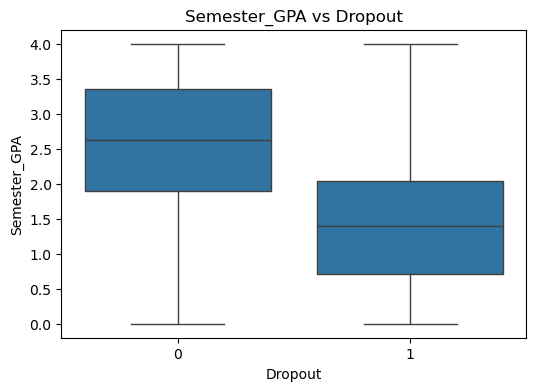

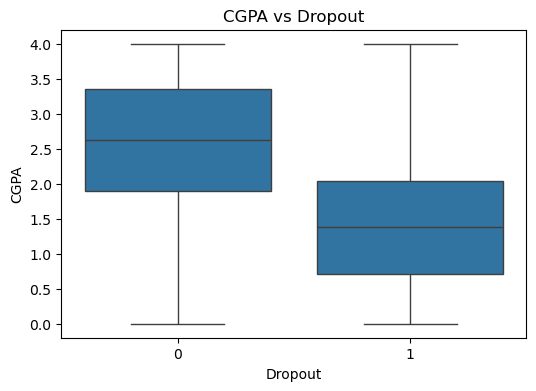

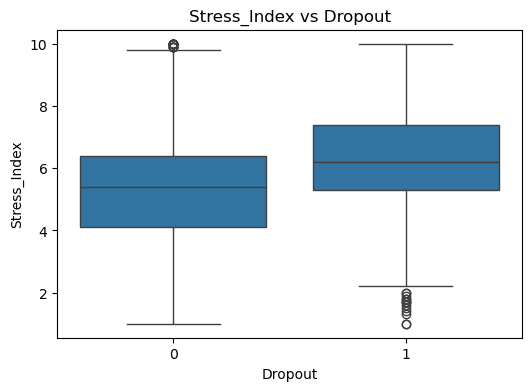

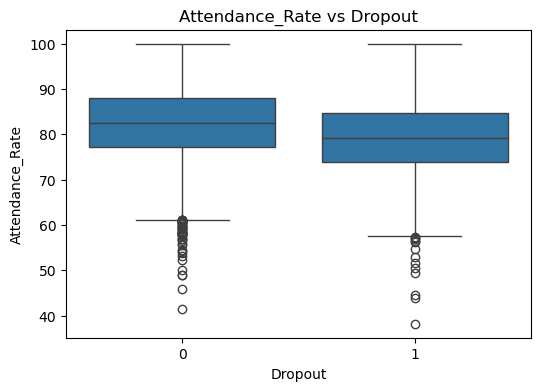

In [24]:
features = ["GPA", "Semester_GPA", "CGPA", "Stress_Index", "Attendance_Rate"]

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Dropout", y=col, data=df)
    plt.title(f"{col} vs Dropout")
    plt.show()

## Train Test Split

In [25]:
X = df.drop(columns='Dropout')
y = df['Dropout']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Scaler

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## SMOTE

In [28]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

## Logistic Regression

In [29]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [31]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

[[1129  400]
 [ 115  356]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1529
           1       0.47      0.76      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.80      0.74      0.76      2000

ROC AUC: 0.8191274426897394


## XGBoost

In [43]:
model_xgb = XGBClassifier(eval_metric='error', random_state=42, scale_pos_weight=3.25)
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'error'


In [44]:
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [45]:
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

[[1263  266]
 [ 201  270]]
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1529
           1       0.50      0.57      0.54       471

    accuracy                           0.77      2000
   macro avg       0.68      0.70      0.69      2000
weighted avg       0.78      0.77      0.77      2000

ROC AUC: 0.7763452237630858


In [74]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

parameters = {
    'max_depth': range (2, 10, 1),
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.1, 0.05, 0.01],
    'colsample_bytree': [0.8, 0.9, 1]
}

grid_obj = GridSearchCV(estimator=model_xgb, param_grid=parameters, scoring='recall', cv=skf)
grid_fit = grid_obj.fit(X_train, y_train)

In [75]:
grid_fit.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.01,
 'max_depth': 2,
 'n_estimators': 100}

In [76]:
best_clf = grid_fit.best_estimator_
y_pred_best = best_clf.predict(X_test)
y_proba_best = best_clf.predict_proba(X_test)[:, 1]

In [77]:
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best))

[[1089  440]
 [ 120  351]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1529
           1       0.44      0.75      0.56       471

    accuracy                           0.72      2000
   macro avg       0.67      0.73      0.68      2000
weighted avg       0.79      0.72      0.74      2000

ROC AUC: 0.8042487839491002


## Conclusion

### Although XGBoost was tested and tuned using class weighting and GridSearchCV with StratifiedKFold, Logistic Regression achieved slightly better performance on the dropout class. It produced higher recall, F1-score, and ROC AUC, making it the better final model for this dataset. This suggests that a simpler linear model captured the available patterns more effectively than the more complex tree-based approach.

In [78]:
print(f"XGBoost (tuned) \n\n {classification_report(y_test, y_pred_best)}\n {'='*100}\n\nLogistic Regression \n\n {classification_report(y_test, y_pred)}")

XGBoost (tuned) 

               precision    recall  f1-score   support

           0       0.90      0.71      0.80      1529
           1       0.44      0.75      0.56       471

    accuracy                           0.72      2000
   macro avg       0.67      0.73      0.68      2000
weighted avg       0.79      0.72      0.74      2000


Logistic Regression 

               precision    recall  f1-score   support

           0       0.91      0.74      0.81      1529
           1       0.47      0.76      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.80      0.74      0.76      2000

